# Prepare Data — NWB (Nationaal Wegenbestand)

**Input files (in `data/raw/`):**
- `Wegvakken.gpkg` — NWB road segments, each with junction IDs at start/end
- `rotterdam_ring.geojson` — custom polygon defining the area of interest

**Output:** `data/processed/intersections.gpkg`

**Coordinate system:** RD New (EPSG:28992) — NWB is already in this projection.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import osmnx as ox
from shapely.geometry import Point

# Base project directory — all paths are relative to this
PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections"

# Input paths
# wegvakken_rotterdam.gpkg is produced by preprocess_nwb.py — it already contains
# only Rotterdam roads, so there is no need to reload the full 1.6M-row national file here.
WEGVAKKEN_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam.gpkg")
RING_PATH      = os.path.join(PROJECT_DIR, "data", "raw", "rotterdam_ring.geojson")
# Output 
OUT_INTERSECTIONS = os.path.join(PROJECT_DIR, "data", "processed", "intersections.gpkg")

CRS_RD = "EPSG:28992"  # RD New — Dutch national projection in metres

# Minimum number of road segments connecting to a junction to count as an intersection
MIN_CONNECTIONS = 3

# Road types (BST_CODE) to include — only "normal" roads.
# RB=rijbaan, ERF=erf/woonerf, HR=hoofdrijbaan
INCLUDE_BST = {"RB", "ERF", "HR"}

os.makedirs(os.path.join(PROJECT_DIR, "data", "processed"), exist_ok=True)
print("Setup complete.")


Setup complete.


## 1. Load and filter wegvakken

`wegvakken_rotterdam.gpkg` is the preprocessed output of `preprocess_nwb.py` —
already filtered to Rotterdam gemeente-managed roads (WEGBEHSRT='G').
We apply the BST_CODE filter here to keep only "normal" driveable road types.


In [2]:
# Load preprocessed Rotterdam wegvakken — gemeente-managed roads only.
# The GME_NAAM and WEGBEHSRT='G' filters were already applied by preprocess_nwb.py,
# so this file is much smaller than the full national dataset.
print("Loading wegvakken_rotterdam.gpkg ...")
wegvakken = gpd.read_file(WEGVAKKEN_PATH)
print(f"Loaded: {len(wegvakken):,} segments (gemeente-managed, Rotterdam only)")

# Filter to relevant road types — excludes footpaths (FP), cycleways, parking (PAR/PP)
wegvakken = wegvakken[wegvakken["BST_CODE"].isin(INCLUDE_BST)].copy()
print(f"After BST_CODE filter: {len(wegvakken):,}")
print()
print("BST_CODE distribution after filter:")
print(wegvakken["BST_CODE"].value_counts())
print()
print("WEGBEHSRT distribution after filter:")
print(wegvakken["WEGBEHSRT"].value_counts())


Loading wegvakken_rotterdam.gpkg ...
Loaded: 40,115 segments (gemeente-managed, Rotterdam only)
After BST_CODE filter: 26,858

BST_CODE distribution after filter:
BST_CODE
RB     25691
HR       633
ERF      534
Name: count, dtype: int64

WEGBEHSRT distribution after filter:
WEGBEHSRT
G    25881
T      708
R      150
P       66
W       53
Name: count, dtype: int64


## 2. Extract junction point geometries

Each wegvak (road segment) is a linestring that runs from `JTE_ID_BEG` to `JTE_ID_END`.
The first coordinate of the linestring is the location of `JTE_ID_BEG`,
and the last coordinate is the location of `JTE_ID_END`.

We extract these endpoint coordinates to build a point GeoDataFrame of all junctions.

In [3]:
print("Extracting junction geometries from linestring endpoints...")

# Start points — JTE_ID_BEG is located at the first coordinate of each linestring
starts = wegvakken[["JTE_ID_BEG", "geometry"]].copy()
starts["point"] = starts["geometry"].apply(lambda g: Point(g.coords[0]))
starts = starts.rename(columns={"JTE_ID_BEG": "JTE_ID"})[["JTE_ID", "point"]]

# End points — JTE_ID_END is located at the last coordinate of each linestring
ends = wegvakken[["JTE_ID_END", "geometry"]].copy()
ends["point"] = ends["geometry"].apply(lambda g: Point(g.coords[-1]))
ends = ends.rename(columns={"JTE_ID_END": "JTE_ID"})[["JTE_ID", "point"]]

# Combine start and end points, then deduplicate — each junction has one location
all_junctions = pd.concat([starts, ends], ignore_index=True)
all_junctions = all_junctions.drop_duplicates(subset="JTE_ID")
print(f"Unique junctions found: {len(all_junctions):,}")

Extracting junction geometries from linestring endpoints...
Unique junctions found: 21,568


## 3. Count road segments per junction

A junction is an intersection if 3 or more road segments connect to it.

We count how many wegvakken reference each junction ID (as start or end point).

In [4]:
# Count how many wegvakken start at each junction
beg_counts = wegvakken["JTE_ID_BEG"].value_counts()

# Count how many wegvakken end at each junction
end_counts  = wegvakken["JTE_ID_END"].value_counts()

# Total connections = segments starting + segments ending at each junction
connection_counts = beg_counts.add(end_counts, fill_value=0).astype(int)
connection_counts.name = "street_count"

# Attach street counts to junction points
all_junctions = all_junctions.set_index("JTE_ID")
all_junctions["street_count"] = connection_counts
all_junctions = all_junctions.reset_index()

# Keep only true intersections — junctions where MIN_CONNECTIONS or more roads meet
intersections_gdf = all_junctions[all_junctions["street_count"] >= MIN_CONNECTIONS].copy()
intersections_gdf = gpd.GeoDataFrame(
    intersections_gdf,
    geometry="point",
    crs=CRS_RD
).rename_geometry("geometry")

print(f"Junctions with {MIN_CONNECTIONS}+ connections: {len(intersections_gdf):,}")
print()
print("Distribution of street counts:")
print(intersections_gdf["street_count"].value_counts().sort_index())

Junctions with 3+ connections: 11,309

Distribution of street counts:
street_count
3    8570
4    2674
5      62
6       3
Name: count, dtype: int64


## 4. Clip to Rotterdam ring area of interest

In [5]:
# Load the ring polygon and reproject to RD New
ring = gpd.read_file(RING_PATH).to_crs(CRS_RD)
ring_polygon = ring.union_all()

# Keep only intersections inside the ring
intersections_gdf = intersections_gdf[
    intersections_gdf.within(ring_polygon)
].copy()

print(f"Intersections inside ring: {len(intersections_gdf):,}")

Intersections inside ring: 5,846


## 5. Visualise result

C:\Users\Thijs\AppData\Local\Temp\ipykernel_21300\1189413974.py:17: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


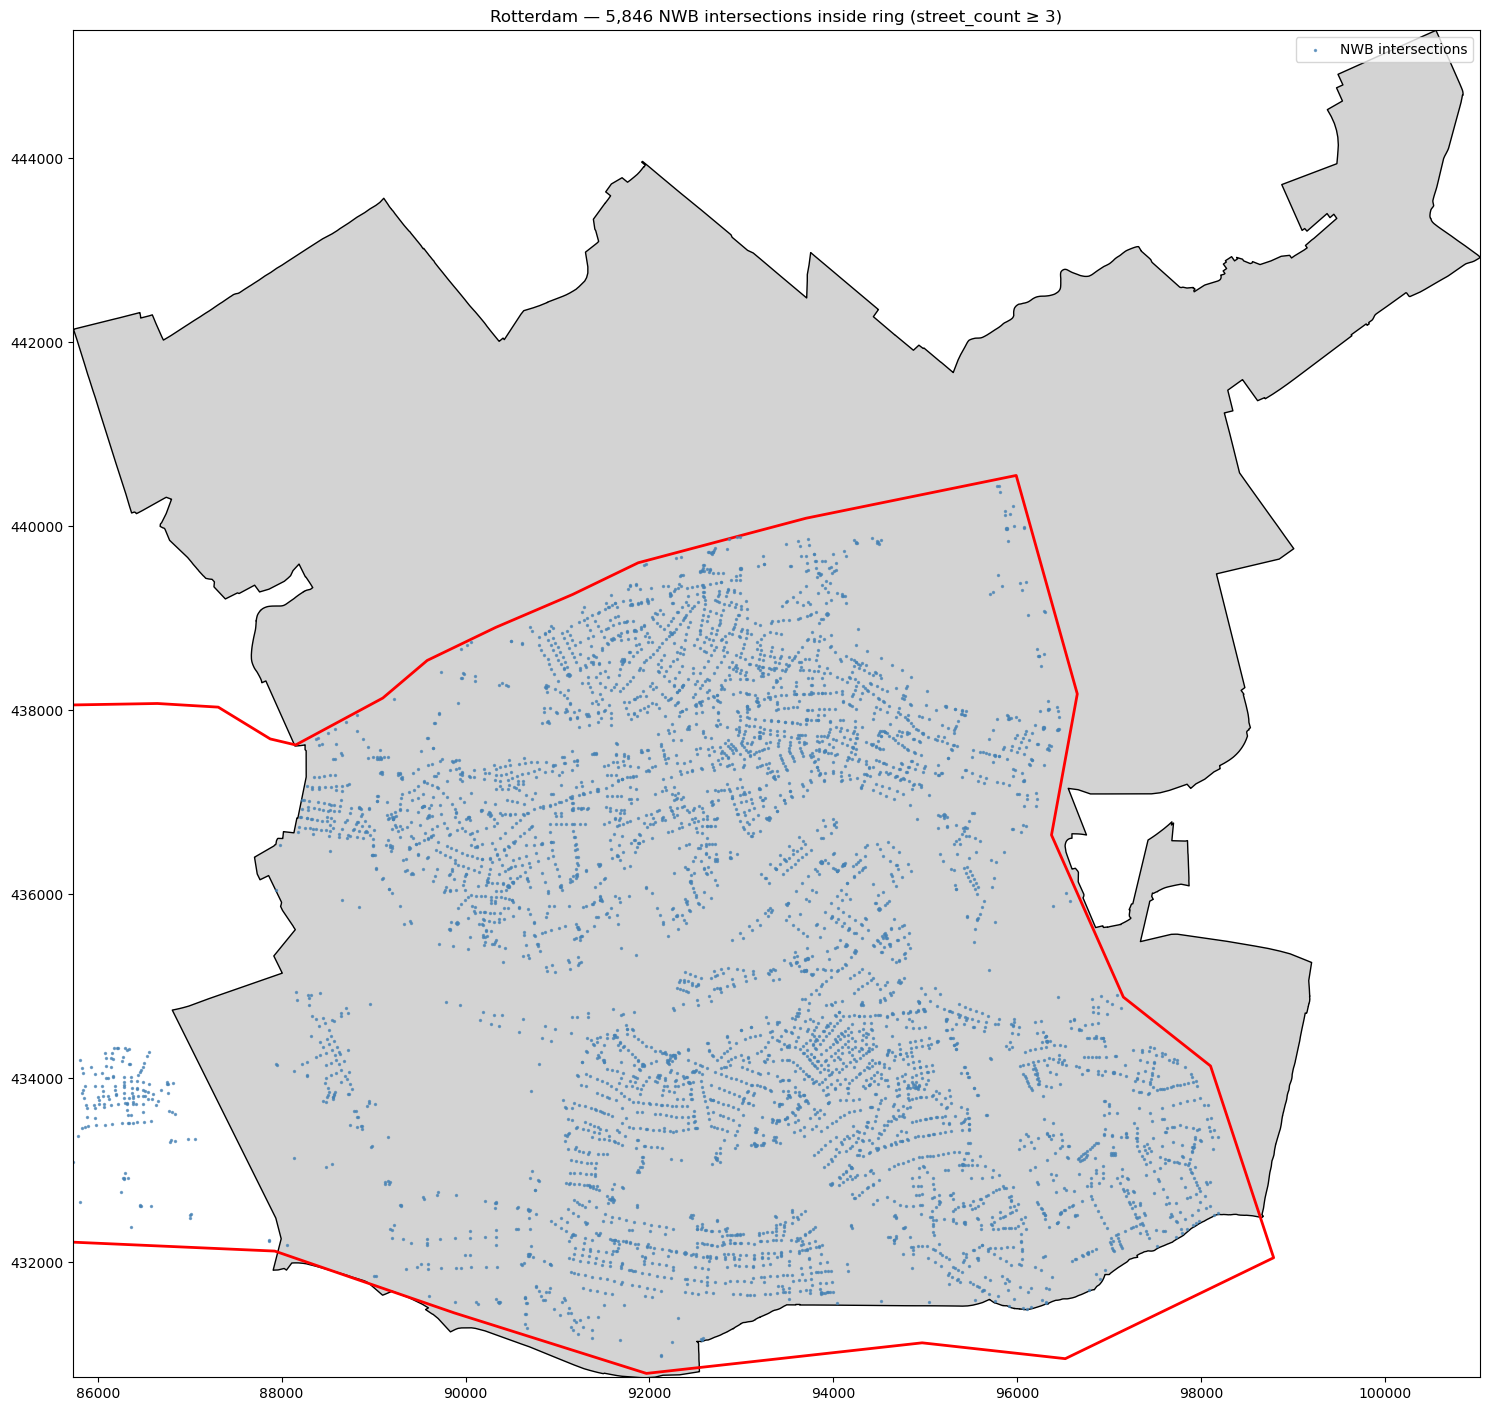

In [6]:
# Download Rotterdam municipality boundary from OSM at runtime -- no local file needed.
# geocode_to_gdf fetches the official admin boundary polygon for Rotterdam gemeente.
rotterdam = ox.geocode_to_gdf("Rotterdam, Netherlands").to_crs(CRS_RD)
minx, miny, maxx, maxy = rotterdam.total_bounds

fig, ax = plt.subplots(figsize=(15, 15))

# Background: Rotterdam municipality polygon
rotterdam.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=1)

# Ring boundary and intersections on top
ring.plot(ax=ax, color="none", edgecolor="red", linewidth=2, label="Ring")
intersections_gdf.plot(ax=ax, color="steelblue", markersize=2, alpha=0.7, label="NWB intersections")

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.legend()
ax.set_title(
    f"Rotterdam — {len(intersections_gdf):,} NWB intersections inside ring "
    f"(street_count ≥ {MIN_CONNECTIONS})"
)
plt.tight_layout()
plt.show()


## 6. Save

Saves to `intersections.gpkg` so notebooks 02, 04, and 05 load NWB intersections without any changes.

In [7]:
# Set JTE_ID as the index — notebook 04 uses .loc[junction_id] for lookups
intersections_gdf = intersections_gdf.set_index("JTE_ID")

intersections_gdf.to_file(OUT_INTERSECTIONS, driver="GPKG")
print(f"Saved {len(intersections_gdf):,} intersections to:")
print(f"  {OUT_INTERSECTIONS}")
print()
print("You can now run notebooks 02, 04, and 05 — they will use NWB intersections.")

Saved 5,846 intersections to:
  C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\intersections.gpkg

You can now run notebooks 02, 04, and 05 — they will use NWB intersections.
